# 13 - Sampling ω_dm,tot instead of ω_cdm

The parent density is f_acc·ω_cdm on top of ω_cdm, so the total cold dark matter before the transition
(scaled to today as a⁻³) is ω_dm,tot = ω_cdm(1 + f_acc). Today the daughters carry the parent's energy,
so ω_dm,tot is also today's ω_cdm + ω_daughter, up to the daughters' leftover kinetic energy.
`omega_dm_tot` can replace `omega_cdm` as input; CLASS sets ω_cdm = ω_dm,tot/(1 + f_acc).

| inputs | ω_cdm | parent (before) ≈ daughter (today) |
|---|---|---|
| ω_cdm, f_acc | input | f_acc ω_cdm |
| ω_dm,tot, f_acc | ω_dm,tot/(1 + f_acc) | ω_dm,tot f_acc/(1 + f_acc) |

**Result.**
- Same model: both inputs give identical spectra, and giving both is rejected (section 1).
- ω_dm,tot is today's total CDM to within the daughters' kinetic energy: 2.7% of the daughter density at
  10¹¹ GeV, 0.2% at 10¹² GeV, below 10⁻⁵ from 10¹⁵ GeV up (section 1b).
- The data measure ω_dm,tot, not ω_cdm, wherever f_acc can move. In the current chains the width of
  ω_dm,tot is 6.5·10⁻⁴ at every mass, while ω_cdm widens with f_acc as it slides along
  ω_dm,tot/(1 + f_acc): 1.1× that at 10¹¹ GeV, 1.7× at 10¹⁴, 13× at 10^15.7 (section 2).
- For an emulator the ω_cdm ridge is curved and narrows as 1/(1 + f_acc); a Latin hypercube in
  (ω_cdm, f_acc) puts ~8× fewer points on it than one in (ω_dm,tot, f_acc), and 10× fewer at
  f_acc > 1 (section 3).
- The only physical difference is the prior: flat in ω_cdm equals flat in ω_dm,tot times 1/(1 + f_acc).
  For the current chains (f̃ ≤ 0.3) it would lower the 95% f̃ limits by at most 9% (section 4).

CLASS runs use the settings of the `connect/new` chains and their 10¹⁴ GeV best fit (fixed values, see
`accdm_nb`). Chain sections use the current chains in `chains/fixed_masses/k12.1a0.133` (flat in
ω_dm,tot and f̃, DE sink on), 30% burn-in.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

from accdm_nb import (CONNECT_NEW, LCDM_NEW14_OCT01, OMEGA_DM_TOT_OCT01, RunCache, chains_dir, load_chain,
                      mass_dirs, ok, status, show, wmean, wquantile, wstd, ess, plot_style)

plot_style()

LCDM, OMEGA_DM_TOT = LCDM_NEW14_OCT01, OMEGA_DM_TOT_OCT01
SAMPLES = {float(d.name): load_chain(d) for d in mass_dirs(chains_dir('k12.1a0.133'))}
print('chains (log10 m):', ', '.join('{:g}'.format(m) for m in SAMPLES))

chains (log10 m): 11, 12, 13, 14, 15, 15.301, 15.699


## 1. Same model, two inputs

At m = 10¹⁶ GeV, each f_acc is run from ω_dm,tot and from ω_cdm = ω_dm,tot/(1 + f_acc). The last run
gives both, which must fail.

In [2]:
def summary(cosmo):
    cl = cosmo.lensed_cl(2500)
    return {**{s: np.asarray(cl[s])[2:] for s in ('tt', 'ee', 'te', 'pp')},
            'omega_cdm': cosmo.Omega0_cdm()*cosmo.h()**2, 'sigma8': cosmo.sigma8(), '100theta_s': cosmo.theta_s_100()}


F_TEST = [1e-6, 0.3, 1.0, 5.0, 10.0]
common = {**CONNECT_NEW, **LCDM, 'm_acc_in_GeV': 1e16}
jobs = [{**common, 'f_acc': f, 'omega_dm_tot': OMEGA_DM_TOT} for f in F_TEST] \
     + [{**common, 'f_acc': f, 'omega_cdm': OMEGA_DM_TOT/(1 + f)} for f in F_TEST] \
     + [{**common, 'f_acc': 1.0, 'omega_dm_tot': OMEGA_DM_TOT, 'omega_cdm': 0.06}]
out = RunCache('13_cache.pkl', extract=summary, workers=8).many(jobs)
rows = []
for f, a, b in zip(F_TEST, out[:5], out[5:10]):
    assert ok(a) and ok(b), (status(a), status(b))
    rows.append({'f_acc': f, 'omega_cdm': a['omega_cdm'], 'sigma8': a['sigma8'],
                 'max |ΔC_l|/max C_l': max(np.max(np.abs(a[s] - b[s]))/np.max(np.abs(b[s])) for s in ('tt', 'ee', 'te', 'pp')),
                 '|Δsigma8|': abs(a['sigma8'] - b['sigma8'])})
show(pd.DataFrame(rows).set_index('f_acc'), {'omega_cdm': '{:.6f}', 'sigma8': '{:.5f}'}, default='{:.1e}')
print('both inputs given:', status(out[-1]))
assert max(r['max |ΔC_l|/max C_l'] for r in rows) < 1e-10 and 'error' in out[-1]

11 new CLASS runs in 84 s


,omega_cdm,sigma8,max |ΔC_l|/max C_l,|Δsigma8|
f_acc,,,,
0.000001,0.117641,0.80728,0.0e+00,0.0e+00
0.300000,0.090493,0.74337,0.0e+00,0.0e+00
1.000000,0.058821,0.67509,0.0e+00,0.0e+00
5.000000,0.019607,0.60165,0.0e+00,0.0e+00
10.000000,0.010695,0.58690,0.0e+00,0.0e+00


both inputs given: CosmoSevereError: =>input_read_parameters_species(L:2599) :condition (((flag1 == _TRUE_) || (flag2 == _TRUE_))) is true;


### 1b. ω_dm,tot today

Background only, f_acc = 1. The daughters' kinetic energy (equation of state w > 0) adds to their
rest-mass density, so ω_cdm + ω_daughter today exceeds ω_dm,tot by a share that falls with mass.

In [3]:
def today(cosmo):
    bg, h2 = cosmo.get_background(), cosmo.h()**2
    return {'omega_cdm': cosmo.Omega0_cdm()*h2, 'omega_d': bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]*h2,
            'w': bg['(.)p_ncdm[1]'][-1]/bg['(.)rho_ncdm[1]'][-1]}


LOG10M = [11, 11.5, 12, 13, 14, 15, 16, 17, 18]
out = RunCache('13_cache.pkl', extract=today, level=['background'], workers=8).many(
    [{**CONNECT_NEW, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT, 'm_acc_in_GeV': 10**lm, 'f_acc': 1.0} for lm in LOG10M])
rows = [{'log10 m': lm, 'omega_cdm + daughter': o['omega_cdm'] + o['omega_d'],
         'excess / daughter': (o['omega_cdm'] + o['omega_d'] - OMEGA_DM_TOT)/o['omega_d'], 'w today': o['w']}
        for lm, o in zip(LOG10M, out)]
print('omega_dm_tot = {:.6f}'.format(OMEGA_DM_TOT))
show(pd.DataFrame(rows).set_index('log10 m'), {'omega_cdm + daughter': '{:.6f}'}, default='{:.1e}')

9 new CLASS runs in 1 s
omega_dm_tot = 0.117642


,omega_cdm + daughter,excess / daughter,w today
log10 m,,,
11.0,0.119250,2.7e-02,1.7e-02
11.5,0.118039,6.7e-03,4.5e-03
12.0,0.117756,1.9e-03,1.3e-03
13.0,0.117652,1.9e-04,1.2e-04
14.0,0.117643,1.8e-05,1.2e-05
15.0,0.117642,1.1e-06,1.2e-06
16.0,0.117641,-6.1e-07,1.2e-07
17.0,0.117641,-7.8e-07,1.2e-08
18.0,0.117641,-8.0e-07,1.2e-09


## 2. What the chains constrain

Posterior widths of ω_cdm and ω_dm,tot and their correlation with f_acc. Where f_acc stays at 0 the two
coincide; where f_acc moves, ω_cdm spreads along ω_dm,tot/(1 + f_acc) and the *sd ratio* grows.

,mean f_acc,95% f_acc,sd omega_cdm,sd omega_dm_tot,"corr(omega_cdm, f)","corr(omega_dm_tot, f)",sd ratio
log10 m,,,,,,,
11.000,0.00208,0.00606,0.000698,0.000645,-0.394,-0.071,1.08
12.000,0.00421,0.0123,0.000777,0.000649,-0.556,0.0452,1.2
13.000,0.00585,0.0168,0.000847,0.000638,-0.667,0.103,1.33
14.000,0.00903,0.0264,0.00114,0.000657,-0.823,0.07,1.74
15.000,0.0261,0.0774,0.00279,0.000651,-0.973,0.0745,4.28
15.301,0.0405,0.123,0.00424,0.000659,-0.986,0.0945,6.44
15.699,0.0888,0.29,0.00883,0.000661,-0.967,0.0823,13.4


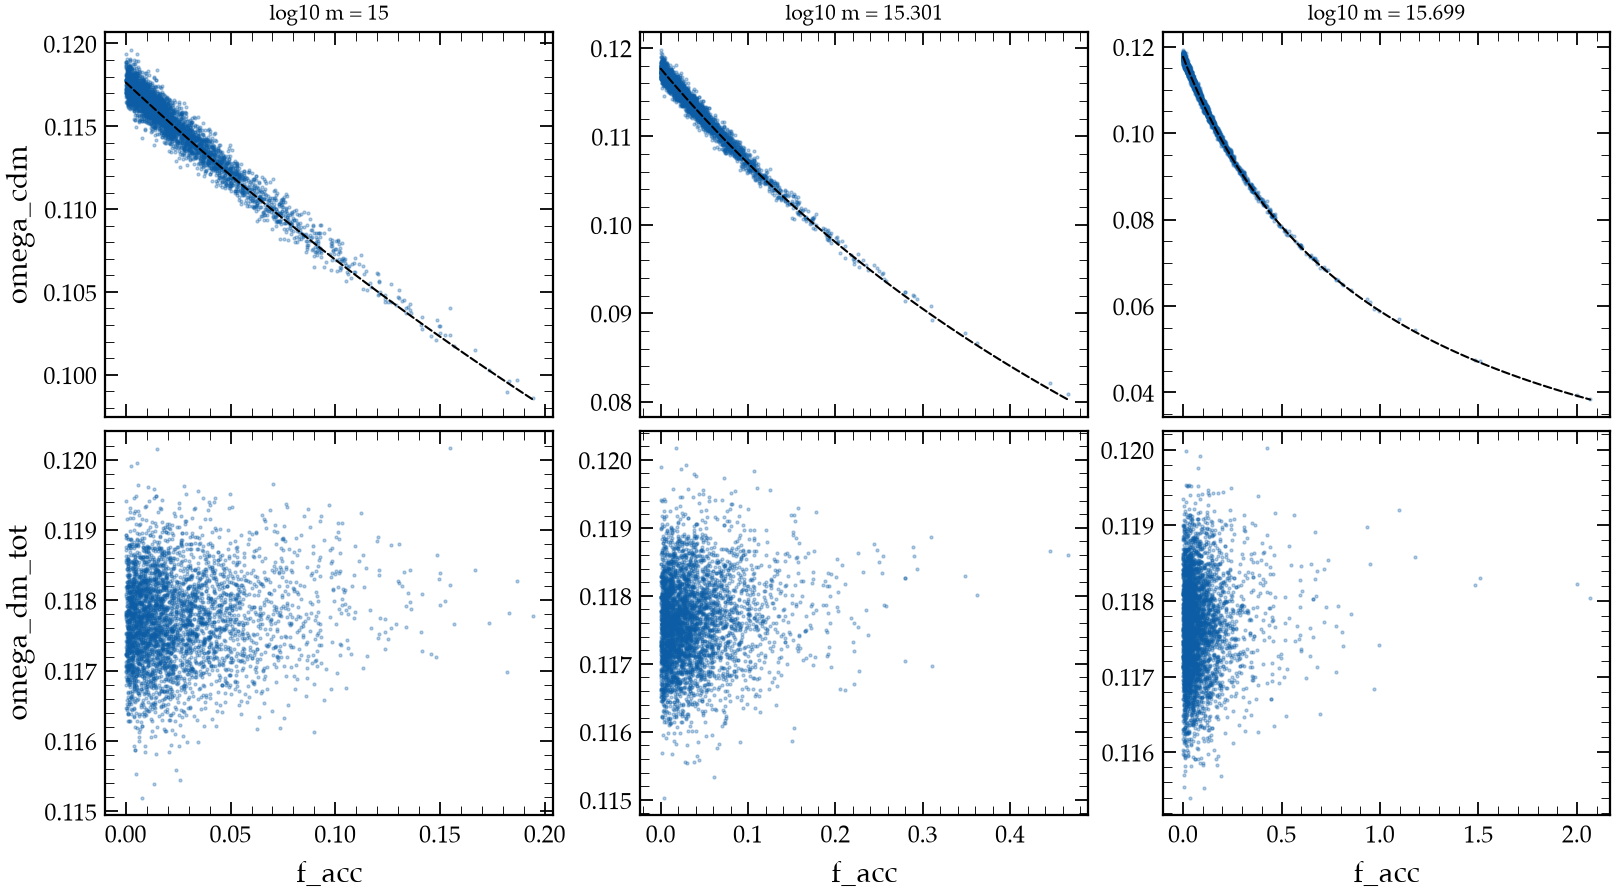

In [4]:
def wcorr(x, y, w):
    return wmean((x - wmean(x, w))*(y - wmean(y, w)), w)/(wstd(x, w)*wstd(y, w))


rows = []
for m, s in SAMPLES.items():
    w = s['weight']
    rows.append({'log10 m': m, 'mean f_acc': wmean(s['f_acc'], w), '95% f_acc': wquantile(s['f_acc'], w, 0.95),
                 'sd omega_cdm': wstd(s['omega_cdm'], w), 'sd omega_dm_tot': wstd(s['omega_dm_tot'], w),
                 'corr(omega_cdm, f)': wcorr(s['omega_cdm'], s['f_acc'], w),
                 'corr(omega_dm_tot, f)': wcorr(s['omega_dm_tot'], s['f_acc'], w)})
table = pd.DataFrame(rows).set_index('log10 m')
table['sd ratio'] = table['sd omega_cdm']/table['sd omega_dm_tot']
show(table, default='{:.3g}')

SHOW = list(SAMPLES)[-3:]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.6*len(SHOW), 6), sharex='col', squeeze=False, constrained_layout=True)
rng = np.random.default_rng(0)
for j, m in enumerate(SHOW):
    s = SAMPLES[m]
    i = rng.choice(len(s['weight']), 4000, p=s['weight']/s['weight'].sum())
    axes[0, j].scatter(s['f_acc'][i], s['omega_cdm'][i], s=2, alpha=0.3)
    axes[1, j].scatter(s['f_acc'][i], s['omega_dm_tot'][i], s=2, alpha=0.3)
    f = np.linspace(0, s['f_acc'][i].max(), 100)
    axes[0, j].plot(f, OMEGA_DM_TOT/(1 + f), 'k--', lw=1)
    axes[0, j].set_title('log10 m = {:g}'.format(m), fontsize=10)
    axes[1, j].set_xlabel('f_acc')
axes[0, 0].set_ylabel('omega_cdm')
axes[1, 0].set_ylabel('omega_dm_tot')
plt.show()

## 3. Ridge shape and emulator training

At fixed f_acc the high-likelihood region is centred on ω_dm,tot/(1 + f_acc) with width σ/(1 + f_acc) in
the old coordinate, but on ω_dm,tot with constant width σ in the new one. The first CONNECT iteration is a
Latin hypercube over the training box; this counts how many of 8000 points in the (second coordinate,
f_acc) plane fall within ±3σ of the ridge, with σ the median ω_dm,tot width of the chains. Boxes:
ω_cdm ∈ [0.01, 0.15] (old CONNECT files) and ω_dm,tot ∈ [0.09, 0.15], both with f_acc ∈ [0, 10].

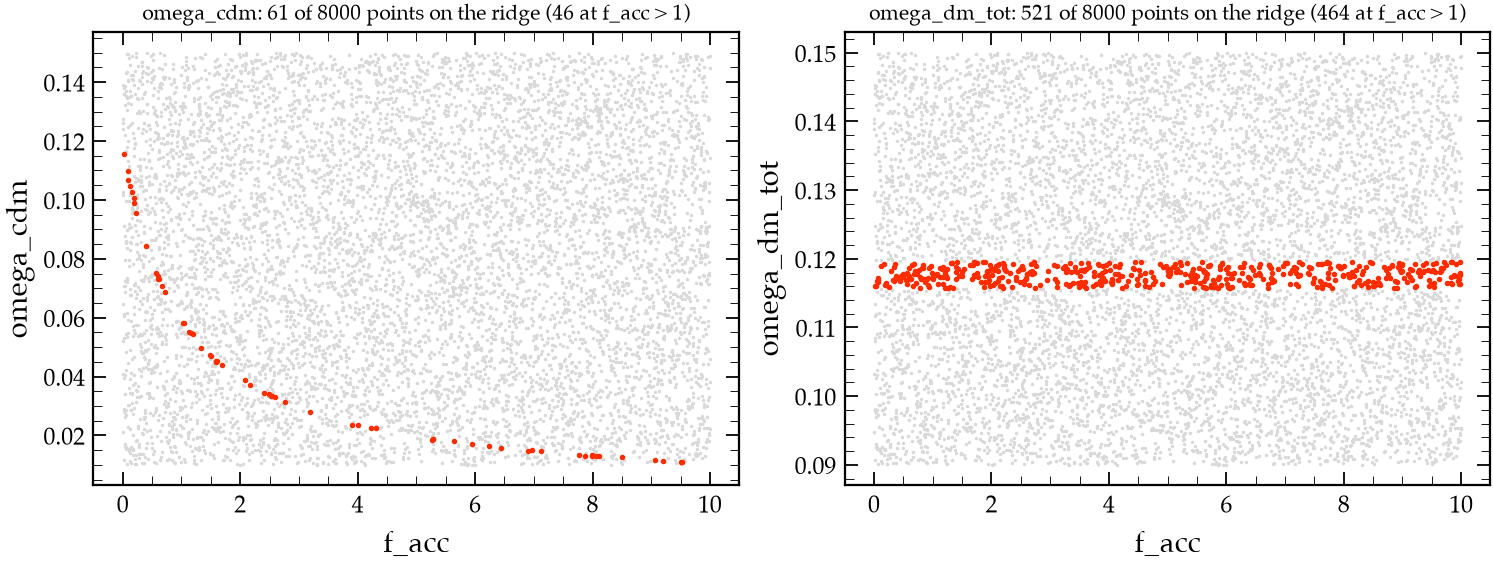

In [5]:
N_LHC = 8000
HALF = 3*float(np.median(table['sd omega_dm_tot']))
lhc = qmc.LatinHypercube(d=2, seed=1).random(N_LHC)
f = 10*lhc[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
for ax, (coord, lo, hi) in zip(axes, [('omega_cdm', 0.01, 0.15), ('omega_dm_tot', 0.09, 0.15)]):
    x = lo + (hi - lo)*lhc[:, 0]
    hit = np.abs((x*(1 + f) if coord == 'omega_cdm' else x) - OMEGA_DM_TOT) < HALF
    ax.scatter(f[~hit], x[~hit], s=1, color='0.85')
    ax.scatter(f[hit], x[hit], s=4, color='C3')
    ax.set_title('{}: {} of {} points on the ridge ({} at f_acc > 1)'.format(
        coord, hit.sum(), N_LHC, (hit & (f > 1)).sum()), fontsize=10)
    ax.set_xlabel('f_acc')
    ax.set_ylabel(coord)
plt.show()

## 4. The prior

The Jacobian of ω_cdm = ω_dm,tot/(1 + f_acc) is 1/(1 + f_acc): a flat ω_cdm prior is a flat ω_dm,tot prior
times 1/(1 + f_acc). The chains are flat in ω_dm,tot; weighting them by 1/(1 + f_acc) previews flat ω_cdm.
Shown for every chain; the ESS ratio says how much of the chain survives the reweighting.

In [6]:
rows = []
for m, s in SAMPLES.items():
    w0, w1 = s['weight'], s['weight']/(1 + s['f_acc'])
    rows.append({'log10 m': m, '95% f̃, flat omega_dm_tot': wquantile(s['f_tilde'], w0, 0.95),
                 '95% f̃, flat omega_cdm': wquantile(s['f_tilde'], w1, 0.95), 'ESS ratio': ess(w1)/ess(w0)})
show(pd.DataFrame(rows).set_index('log10 m'), default='{:.3g}')

,"95% f̃, flat omega_dm_tot","95% f̃, flat omega_cdm",ESS ratio
log10 m,,,
11.000,0.00602,0.00601,1
12.000,0.0121,0.0121,0.999
13.000,0.0166,0.0165,0.998
14.000,0.0257,0.0255,0.997
15.000,0.0719,0.0703,0.992
15.301,0.11,0.106,0.99
15.699,0.225,0.205,0.98
